# Задание 5 — Предобработка данных и PCA

**Датасет:** Credit Card Dataset for Clustering (Kaggle)

В этом ноутбуке: загрузка данных через `kagglehub`, анализ по вопросам 1–13, предобработка, PCA (вопросы 14–15), t‑SNE + кластеризация и интерпретация кластеров (вопрос 16).

Чтобы получить PDF-отчёт: в Colab откройте `Файл → Печать` и сохраните как PDF (или `Файл → Скачать → PDF`, если доступно).

In [1]:
!pip -q install kagglehub pandas numpy scikit-learn matplotlib

In [2]:
import kagglehub
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_ROOT = Path(kagglehub.dataset_download('arjunbhasin2013/ccdata'))
csv_path = sorted(DATA_ROOT.rglob('*.csv'))[0]
data = pd.read_csv(csv_path)
print('CSV:', csv_path.name)
data.head()

Using Colab cache for faster access to the 'ccdata' dataset.
CSV: CC GENERAL.csv


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Описание признаков (если есть)

Ниже — краткое описание колонок из датасета (как обычно приводится в описании набора на Kaggle).

In [3]:
feature_description = {
    'CUST_ID': 'Идентификатор клиента (ID)',
    'BALANCE': 'Средний баланс по счёту',
    'BALANCE_FREQUENCY': 'Частота обновления баланса (0..1)',
    'PURCHASES': 'Сумма покупок',
    'ONEOFF_PURCHASES': 'Сумма разовых покупок',
    'INSTALLMENTS_PURCHASES': 'Сумма покупок в рассрочку',
    'CASH_ADVANCE': 'Сумма снятий наличных',
    'PURCHASES_FREQUENCY': 'Частота покупок (0..1)',
    'ONEOFF_PURCHASES_FREQUENCY': 'Частота разовых покупок (0..1)',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'Частота покупок в рассрочку (0..1)',
    'CASH_ADVANCE_FREQUENCY': 'Частота снятий наличных (0..1)',
    'CASH_ADVANCE_TRX': 'Количество операций снятия наличных',
    'PURCHASES_TRX': 'Количество операций покупок',
    'CREDIT_LIMIT': 'Кредитный лимит',
    'PAYMENTS': 'Сумма платежей',
    'MINIMUM_PAYMENTS': 'Минимальный платёж',
    'PRC_FULL_PAYMENT': 'Доля случаев полного погашения (0..1)',
    'TENURE': 'Срок обслуживания клиента (в месяцах)',
}
desc_df = pd.DataFrame({
    'Признак': data.columns,
    'Описание': [feature_description.get(c, '') for c in data.columns]
})
desc_df

,Признак,Описание
0,CUST_ID,Идентификатор клиента (ID)
1,BALANCE,Средний баланс по счёту
2,BALANCE_FREQUENCY,Частота обновления баланса (0..1)
3,PURCHASES,Сумма покупок
4,ONEOFF_PURCHASES,Сумма разовых покупок
5,INSTALLMENTS_PURCHASES,Сумма покупок в рассрочку
6,CASH_ADVANCE,Сумма снятий наличных
7,PURCHASES_FREQUENCY,Частота покупок (0..1)
8,ONEOFF_PURCHASES_FREQUENCY,Частота разовых покупок (0..1)
9,PURCHASES_INSTALLMENTS_FREQUENCY,Частота покупок в рассрочку (0..1)


## Вопросы 1–13 (анализ датасета)

1) Объектов: 8950
   Признаков: 18
2) Категориальных признаков: 1
   Список: ['CUST_ID']
3) Максимум уникальных значений у: CUST_ID → 8950
4) Бинарные признаки: нет
5) Числовых признаков: 17
   Пример: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY']
6) Пропуски есть? True
7) Объектов с пропусками: 314
8) Больше всего пропусков в: MINIMUM_PAYMENTS → 313
9) Признаки с наибольшей долей выбросов (топ-5):


,column,outlier_fraction
1,BALANCE_FREQUENCY,0.166816
15,PRC_FULL_PAYMENT,0.164693
5,CASH_ADVANCE,0.115084
3,ONEOFF_PURCHASES,0.113184
14,MINIMUM_PAYMENTS,0.097372


10) До стандартизации max(mean): CREDIT_LIMIT → 4494.449450364621
    После стандартизации max(mean): TENURE → 2.9215611928459985e-16
11) Целевого признака в датасете нет (задача без учителя: кластеризация).
12) Train объектов: 6265
13) Топ-10 пар с наибольшей |corr|:


PURCHASES               ONEOFF_PURCHASES                    0.916845
PURCHASES_FREQUENCY     PURCHASES_INSTALLMENTS_FREQUENCY    0.862934
CASH_ADVANCE_FREQUENCY  CASH_ADVANCE_TRX                    0.799561
PURCHASES               PURCHASES_TRX                       0.689561
                        INSTALLMENTS_PURCHASES              0.679896
CASH_ADVANCE            CASH_ADVANCE_TRX                    0.656498
                        CASH_ADVANCE_FREQUENCY              0.628522
INSTALLMENTS_PURCHASES  PURCHASES_TRX                       0.628108
PURCHASES               PAYMENTS                            0.603264
PURCHASES_FREQUENCY     PURCHASES_TRX                       0.568430
Name: corr, dtype: float64

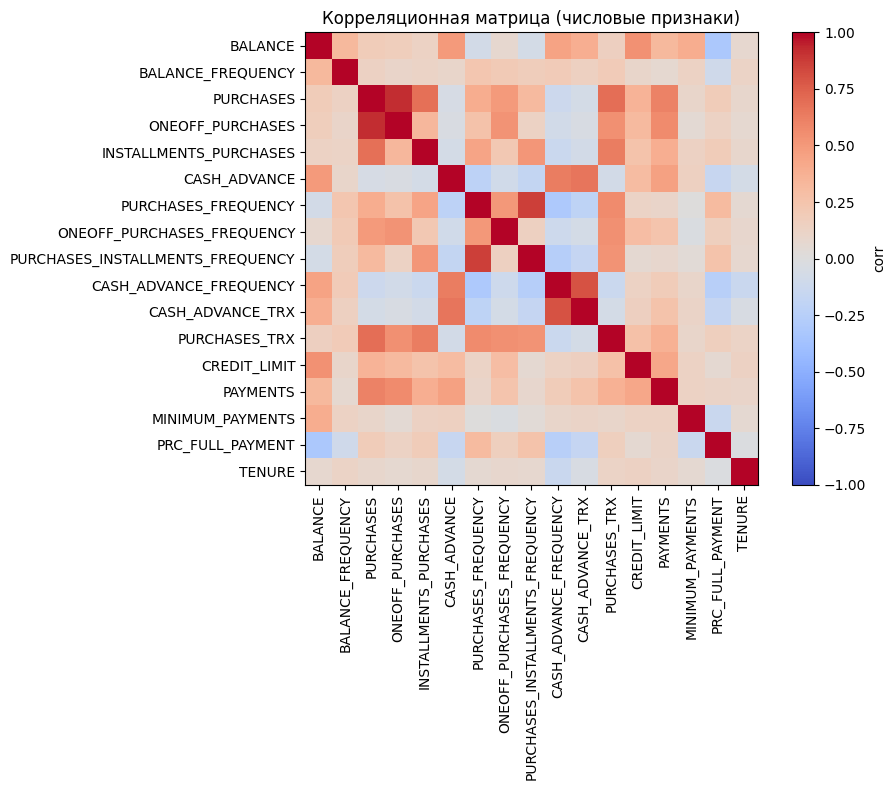

In [4]:
# 1) Сколько объектов и признаков?
n_objects, n_features = data.shape
print('1) Объектов:', n_objects)
print('   Признаков:', n_features)

# 2) Сколько категориальных признаков, какие?
cat_cols = data.select_dtypes(include=['object', 'category']).columns.tolist()
print('2) Категориальных признаков:', len(cat_cols))
print('   Список:', cat_cols)

# 3) Столбец с максимальным числом уникальных значений среди категориальных
if len(cat_cols) > 0:
    nunique_cat = data[cat_cols].nunique(dropna=False).sort_values(ascending=False)
    print('3) Максимум уникальных значений у:', nunique_cat.index[0], '→', int(nunique_cat.iloc[0]))
else:
    print('3) Категориальных признаков нет')

# 4) Есть ли бинарные признаки?
binary_cols = [c for c in data.columns if data[c].nunique(dropna=False) == 2]
print('4) Бинарные признаки:', binary_cols if binary_cols else 'нет')

# 5) Какие числовые признаки?
num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
print('5) Числовых признаков:', len(num_cols))
print('   Пример:', num_cols[:10])

# 6) Есть ли пропуски?
has_missing = data.isna().any().any()
print('6) Пропуски есть?' , bool(has_missing))

# 7) Сколько объектов с пропусками?
rows_with_missing = int(data.isna().any(axis=1).sum())
print('7) Объектов с пропусками:', rows_with_missing)

# 8) Столбец с максимальным количеством пропусков
missing_by_col = data.isna().sum().sort_values(ascending=False)
max_missing_col = missing_by_col.index[0]
print('8) Больше всего пропусков в:', max_missing_col, '→', int(missing_by_col.iloc[0]))

# 9) Есть ли выбросы/аномальные значения? (оценка по правилу IQR)
outlier_info = []
for c in num_cols:
    s = data[c].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        continue
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    frac = float(((s < lower) | (s > upper)).mean())
    outlier_info.append((c, frac))
outlier_df = pd.DataFrame(outlier_info, columns=['column', 'outlier_fraction']).sort_values('outlier_fraction', ascending=False)
print('9) Признаки с наибольшей долей выбросов (топ-5):')
display(outlier_df.head(5))

# 10) Столбец с максимальным средним значением до/после стандартизации
means_before = data[num_cols].mean(numeric_only=True).sort_values(ascending=False)
col_max_mean_before = means_before.index[0]

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_num_imputed = imputer.fit_transform(data[num_cols])
X_scaled = scaler.fit_transform(X_num_imputed)
means_after = pd.Series(X_scaled.mean(axis=0), index=num_cols).sort_values(ascending=False)
col_max_mean_after = means_after.index[0]

print('10) До стандартизации max(mean):', col_max_mean_before, '→', float(means_before.iloc[0]))
print('    После стандартизации max(mean):', col_max_mean_after, '→', float(means_after.iloc[0]))

# 11) Столбец с целевым признаком
print('11) Целевого признака в датасете нет (задача без учителя: кластеризация).')

# 12) Размер train при train_test_split(test_size=0.3, random_state=42)
X_for_split = pd.DataFrame(X_scaled, columns=num_cols)
X_train, X_test = train_test_split(X_for_split, test_size=0.3, random_state=RANDOM_STATE)
print('12) Train объектов:', X_train.shape[0])

# 13) Линейная зависимость (корреляция)
corr = pd.DataFrame(X_num_imputed, columns=num_cols).corr()
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename('corr')
    .abs()
    .sort_values(ascending=False)
)
print('13) Топ-10 пар с наибольшей |corr|:')
display(pairs.head(10))

plt.figure(figsize=(10, 8))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='corr')
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title('Корреляционная матрица (числовые признаки)')
plt.tight_layout()
plt.show()

## PCA (вопросы 14–15)

Перед PCA убираем признаки, которые не имеют смысла для анализа (ID), заполняем пропуски медианой и стандартизируем признаки.

14) Компонент достаточно для 90% дисперсии: 10


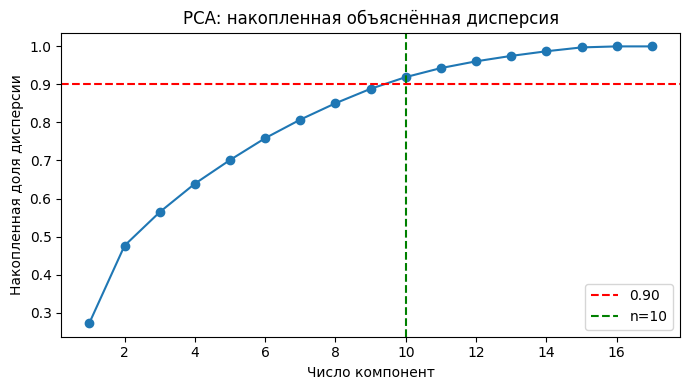

15) Наибольший вклад в 1-ю компоненту: PURCHASES


,abs(loading)
PURCHASES,0.411562
PURCHASES_TRX,0.390599
ONEOFF_PURCHASES,0.346334
INSTALLMENTS_PURCHASES,0.336761
PURCHASES_FREQUENCY,0.321232
ONEOFF_PURCHASES_FREQUENCY,0.294493
PURCHASES_INSTALLMENTS_FREQUENCY,0.274494
PAYMENTS,0.266482
CREDIT_LIMIT,0.211916
PRC_FULL_PAYMENT,0.131833


In [5]:
# Исключаем бессмысленные идентификаторы (если есть)
id_cols = [c for c in data.columns if 'id' in c.lower()]
use_cols = [c for c in data.columns if c not in id_cols]

X_raw = data[use_cols].copy()

# Категориальные (обычно только CUST_ID) исключаем из PCA
cat_cols2 = X_raw.select_dtypes(include=['object', 'category']).columns.tolist()
X_num = X_raw.drop(columns=cat_cols2)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_imputed = imputer.fit_transform(X_num)
X_scaled = scaler.fit_transform(X_imputed)

pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = int(np.argmax(cum_var >= 0.90) + 1)

print('14) Компонент достаточно для 90% дисперсии:', n_90)

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='0.90')
plt.axvline(n_90, color='green', linestyle='--', label=f'n={n_90}')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.title('PCA: накопленная объяснённая дисперсия')
plt.legend()
plt.tight_layout()
plt.show()

# 15) Признак с максимальным вкладом в 1-ю компоненту
pc1_loadings = pd.Series(pca_full.components_[0], index=X_num.columns)
top_feature_pc1 = pc1_loadings.abs().sort_values(ascending=False).index[0]
print('15) Наибольший вклад в 1-ю компоненту:', top_feature_pc1)
display(pc1_loadings.abs().sort_values(ascending=False).head(10).to_frame('abs(loading)'))

## t‑SNE + кластеры (вопрос 16)

Для визуализации сначала уменьшаем размерность PCA до `n_90` компонент (чтобы t‑SNE работал стабильнее и быстрее), затем строим t‑SNE в 2D.

Чтобы объяснить смысл кластеров, применим KMeans (число кластеров подберём по silhouette score) и сравним средние значения признаков по кластерам.

In [6]:
# PCA-редукция до n_90 компонент
pca = PCA(n_components=n_90, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Подбор числа кластеров по silhouette
sil_scores = {}
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    labels = km.fit_predict(X_pca)
    sil_scores[k] = silhouette_score(X_pca, labels)

best_k = max(sil_scores, key=sil_scores.get)
print('Лучшее k по silhouette:', best_k, 'score=', sil_scores[best_k])
display(pd.DataFrame({'k': list(sil_scores.keys()), 'silhouette': list(sil_scores.values())}).sort_values('k'))

plt.figure(figsize=(6, 3))
plt.plot(list(sil_scores.keys()), list(sil_scores.values()), marker='o')
plt.xlabel('k')
plt.ylabel('silhouette')
plt.title('Подбор k по silhouette (на PCA-признаках)')
plt.tight_layout()
plt.show()

# Финальный KMeans
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init='auto')
cluster_labels = kmeans.fit_predict(X_pca)

# t-SNE в 2D
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(7, 5))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels, s=10, cmap='tab10')
plt.title(f't-SNE (2D), k={best_k}')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.colorbar(scatter, label='cluster')
plt.tight_layout()
plt.show()

print('16) Визуально количество кластеров на графике соответствует k=', best_k)

# Интерпретация: какие признаки наиболее 
 для каждого кластера
cluster_means = pd.DataFrame(X_imputed, columns=X_num.columns).assign(cluster=cluster_labels).groupby('cluster').mean()
overall_mean = pd.DataFrame(X_imputed, columns=X_num.columns).mean()
overall_std = pd.DataFrame(X_imputed, columns=X_num.columns).std(ddof=0).replace(0, np.nan)
z_means = (cluster_means - overall_mean) / overall_std

print('Средние значения признаков по кластерам (топ-8 по |z| для каждого кластера):')
for cl in z_means.index:
    top = z_means.loc[cl].abs().sort_values(ascending=False).head(8).index
    print(f'
Кластер {cl}:')
    display(z_means.loc[cl, top].sort_values(ascending=False).to_frame('z-mean'))

IndentationError: unexpected indent (3578018195.py, line 44)